UTS Data Mining_Mufida Aqila Humaidah_2304020127

A. PERSIAPAN DATA

1. Import Data

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

2. Load Data

In [157]:
train_data = pd.read_csv('data_training.csv')
test_data = pd.read_csv('data_testing.csv')

3. Cek Struktur Data

In [158]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [159]:
train_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [160]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [161]:
test_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


B. PEMBERSIHAN DATA

1. Cek Missing Value

In [162]:
train_data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [163]:
test_data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


2. Exploratory Data Analysis (EDA)

a. Distribusi Target

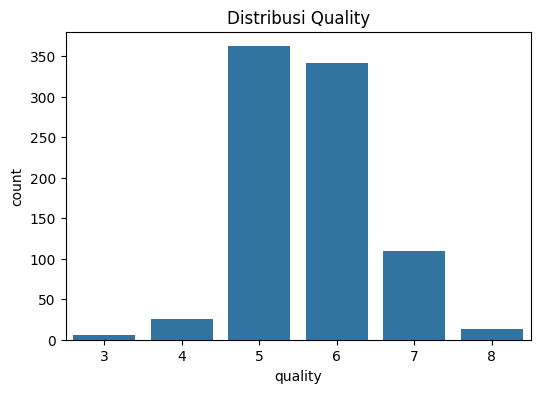

In [164]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='quality')
plt.title("Distribusi Quality")
plt.show()

b. Korelasi Fitur

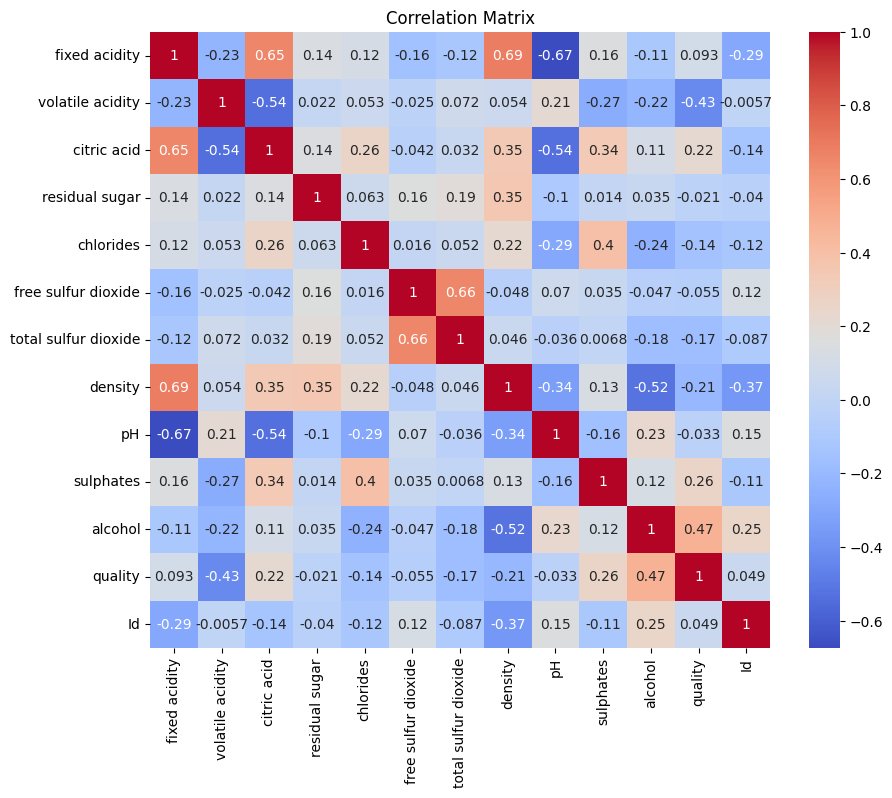

In [165]:
plt.figure(figsize=(10,8))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

3. Preprocessing

a. Pemisahan fitur dan target

In [166]:
X = train_data.drop(['quality', 'Id'], axis=1)
y = train_data['quality']

b. Split data

In [167]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

c. Feature scaling

In [168]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

d. Data testing

In [169]:
X_test = test_data.drop('Id', axis=1)
X_test_scaled = scaler.transform(X_test)

test_ids = test_data['Id']

C. PEMBUATAN MODEL

1. Model Desicion Tree

In [170]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_dt = dt.predict(X_val_scaled)
acc_dt = accuracy_score(y_val, y_dt)

print("Akurasi Decision Tree:", acc_dt)

Akurasi Decision Tree: 0.563953488372093


Berdasarkan hasil output, akurasi model Desicion Tree sebesar 56,39% menunjukkan performa yang masih moderat, yang kemungkinan dipengaruhi oleh kompleksitas data atau ketidakseimbangan kelas, sehingga hasil ini dapat dijadikan acuan untuk evaluasi dan optimasi lebih lanjut.


2. Model Random Forest

In [171]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train_scaled, y_train)

y_rf = rf.predict(X_val_scaled)
acc_rf = accuracy_score(y_val, y_rf)

print("Akurasi Random Forest:", acc_rf)

Akurasi Random Forest: 0.5755813953488372


Berdasarkan hasil output, akurasi model Random Forest sebesar 57,55% menunjukkan peningkatan dibanding model sebelumnya karena kemampuannya dalam menangani hubungan non-linear dan mengurangi varians, meskipun performanya masih dipengaruhi oleh ketidakseimbangan kelas pada dataset.


3. Model Logistic Regression

In [172]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_lr = lr.predict(X_val_scaled)
acc_lr = accuracy_score(y_val, y_lr)

print("Akurasi Logistic Regression:", acc_lr)

Akurasi Logistic Regression: 0.6104651162790697


Berdasarkan hasil output, akurasi model Logistic Regression sebesar 61,05% merupakan yang tertinggi dibanding model sebelumnya, menunjukkan bahwa pola data cenderung memiliki hubungan linear yang cukup kuat dan model ini lebih stabil dalam menangani varians dibandingkan model berbasis pohon.


4. Model K-Nearest Neighbors (KNN)

In [173]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_knn = knn.predict(X_val_scaled)
acc_knn = accuracy_score(y_val, y_knn)

print("Akurasi KNN:", acc_knn)

Akurasi KNN: 0.48255813953488375


Berdasarkan hasil output, akurasi model KNN sebesar 48,25% menunjukkan bahwa pola data cukup kompleks dan saling tumpang tindih, sehingga metode berbasis jarak kurang efektif dan model kesulitan menggeneralisasi data, kemungkinan karena adanya noise atau fitur yang tidak memisahkan kelas dengan jelas dalam ruang Euclidean.

5. Perbandingan Keempat Model

                 Model   Akurasi
0        Decision Tree  0.563953
1        Random Forest  0.575581
2  Logistic Regression  0.610465
3                  KNN  0.482558


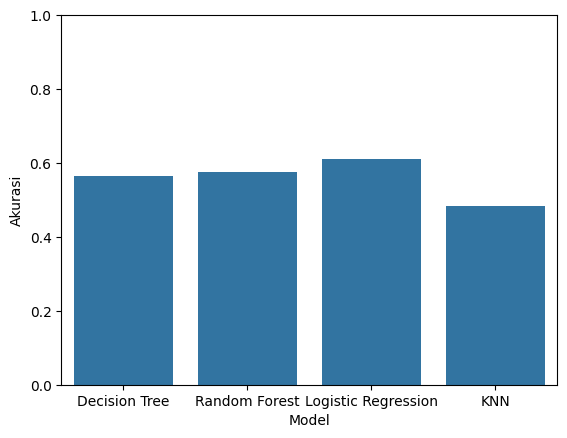

In [174]:
hasil = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'KNN'],
    'Akurasi': [acc_dt, acc_rf, acc_lr, acc_knn]
})

print(hasil)

sns.barplot(data=hasil, x='Model', y='Akurasi')
plt.ylim(0,1)
plt.show()

Berdasarkan hasil output, pada dataset kualitas wine ini model Logistic Regression lebih efektif dalam menangkap hubungan antar fitur dibandingkan model berbasis pohon maupun jarak; namun akurasi sekitar 60% menunjukkan masih adanya tantangan seperti ketidakseimbangan kelas atau overlap fitur, sehingga hasil ini menjadi dasar pemilihan model final untuk prediksi data testing.


6. Evaluasi Model Terbaik (Logistic Regression)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.78      0.72        73
           6       0.55      0.60      0.58        68
           7       0.58      0.32      0.41        22
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.30      0.28      0.29       172
weighted avg       0.58      0.61      0.59       172



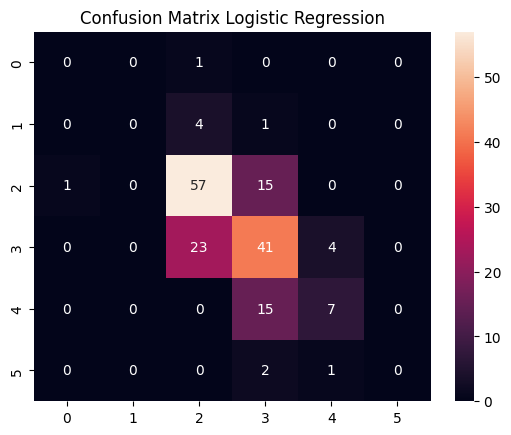

In [175]:
print(classification_report(y_val, y_lr))

cm = confusion_matrix(y_val, y_lr)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Logistic Regression")
plt.show()

Berdasarkan hasil output, model sangat bergantung pada jumlah data (support), terlihat dari kelas mayoritas seperti 5 dan 6 yang memiliki skor F1 masing-masing 0,72 dan 0,58, sementara kelas minoritas (3, 4, dan 8) tidak terprediksi sama sekali (skor 0,00); confusion matrix menunjukkan dominasi prediksi benar pada kelas menengah namun masih banyak misklasifikasi pada kelas yang berdekatan, sehingga meskipun akurasi mencapai 61%, nilai macro average yang rendah (0,29) menandakan adanya bias kuat akibat ketidakseimbangan data dan perlunya strategi penyeimbangan untuk meningkatkan performa pada kelas ekstrem.

7. Cross Validation

In [176]:
cv = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print("CV Mean:", cv.mean())

CV Mean: 0.5912408759124087


Berdasarkan hasil output, nilai CV Mean sebesar 59,12% yang mendekati akurasi validasi (61%) menunjukkan model cukup stabil dan tidak mengalami overfitting signifikan, sehingga dapat dianggap andal untuk prediksi, meskipun masih memiliki keterbatasan dalam menangani seluruh variasi kualitas wine.


8. Hyperparameter Tuning

In [177]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Score: 0.5912050869531909


Berdasarkan hasil output, Best Params ‘C’: 1 dengan Best Score 59,12% menunjukkan bahwa parameter default sudah optimal untuk dataset ini, menandakan model telah melalui proses tuning yang sistematis dan mencapai performa terbaik yang dapat dihasilkan oleh algoritma tersebut.


In [178]:
y_best = best_model.predict(X_val_scaled)
print("Akurasi setelah tuning:", accuracy_score(y_val, y_best))

Akurasi setelah tuning: 0.6104651162790697


Berdasarkan hasil output, akurasi tetap sebesar 61,04% setelah tuning, yang menunjukkan bahwa model sudah berada pada kondisi optimal dengan parameter default (C=1), sehingga proses tuning tidak memberikan peningkatan signifikan; hal ini juga menandakan model cukup stabil dan tidak mengalami overfitting sebelum digunakan pada data testing akhir.


D. PREDIKSI DATA UJI

1. Prediksi Data Testing

In [179]:
final_pred = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'Id': test_ids,
    'quality': final_pred
})

print(submission.head())

     Id  quality
0   222        5
1  1514        5
2   417        5
3   754        5
4   516        6


Berdasarkan hasil output, setiap baris pada file tersebut merepresentasikan keputusan akhir model berdasarkan pola yang telah dipelajari saat pelatihan, dengan kolom *quality* berisi prediksi kategori kualitas wine untuk setiap ID; hasil ini menunjukkan implementasi dari model yang telah divalidasi sebelumnya, sehingga file yang dihasilkan dapat digunakan sebagai output akhir untuk menilai kualitas wine secara otomatis dengan tingkat keandalan sesuai akurasi yang diperoleh.


2. Menyimpan CSV

In [180]:
submission.to_csv('hasilprediksi_127.csv', index=False)

3. Mendownload CSV

In [181]:
from google.colab import files
files.download('hasilprediksi_127.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4. Verifikasi

In [182]:
print(submission.columns)
print(len(submission), len(test_data))

Index(['Id', 'quality'], dtype='object')
286 286


Berdasarkan hasil output, format data sudah benar dengan jumlah 286 data yang sesuai, sehingga tidak ditemukan data yang hilang maupun terduplikasi; hal ini menunjukkan pipeline berjalan stabil dan hasil prediksi sudah siap digunakan.


E. KESIMPULAN

Berdasarkan hasil analisis, dapat disimpulkan bahwa Logistic Regression merupakan model terbaik untuk mengklasifikasikan kualitas anggur dibandingkan Decision Tree, Random Forest, dan KNN, dengan akurasi tertinggi sebesar **61,05%**, yang menunjukkan bahwa pola dalam data cenderung linear sehingga lebih sesuai dimodelkan menggunakan pendekatan linear. Meskipun model menunjukkan performa yang cukup baik dan stabil dalam memprediksi data, masih terdapat potensi bias terutama pada kelas kualitas menengah yang disebabkan oleh ketidakseimbangan distribusi kelas dalam dataset, sementara fitur kimia seperti kadar alkohol dan tingkat keasaman diduga memiliki pengaruh yang signifikan terhadap hasil prediksi. Secara keseluruhan, proses preprocessing, pemodelan, serta evaluasi yang dilakukan secara sistematis telah menghasilkan model yang cukup andal dan dapat digunakan sebagai dasar untuk analisis lebih lanjut, meskipun masih terdapat ruang untuk peningkatan performa melalui optimasi model dan penyeimbangan data.
